# RFM Feature Engineering & Customer Segmentation

Builds on the EDA findings to construct RFM metrics, score them, and assign rule-based customer segments.

Inputs:  data/processed/final_dataset.csv  
Outputs: data/processed/rfm_segments.csv  (produced by pipeline.py)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
df = pd.read_csv(BASE_DIR / "data/processed/final_dataset.csv",
                 parse_dates = ["order_purchase_timestamp"])

print(f"Shape: {df.shape}")
df.head()

Shape: (96478, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,num_items,total_price,total_freight
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1,19.90,8.72


## RFM Metrics

RFM summarises customer behaviour using only transaction history:
- **Recency** — days since last purchase (lower = more engaged)
- **Frequency** — number of unique orders
- **Monetary** — total payment value (BRL)

In [3]:
reference_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

Reference date: 2018-08-30


In [4]:
rfm = (
    df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase = ("order_purchase_timestamp", "max"),
        frequency     = ("order_id", "nunique"),
        monetary      = ("payment_value", "sum")
    )
)

rfm["recency"] = (reference_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns=["last_purchase"])

print(f"Customers: {len(rfm):,}")
rfm.describe()

Customers: 93,358


,frequency,monetary,recency
count,93358.000000,93358.000000,93358.000000
mean,1.033420,165.197003,237.941773
std,0.209097,226.314012,152.591453
min,1.000000,0.000000,1.000000
25%,1.000000,63.052500,114.000000
50%,1.000000,107.780000,219.000000
75%,1.000000,182.557500,346.000000
max,15.000000,13664.080000,714.000000


## Distributions

Checking raw distributions before scoring to validate the approach.

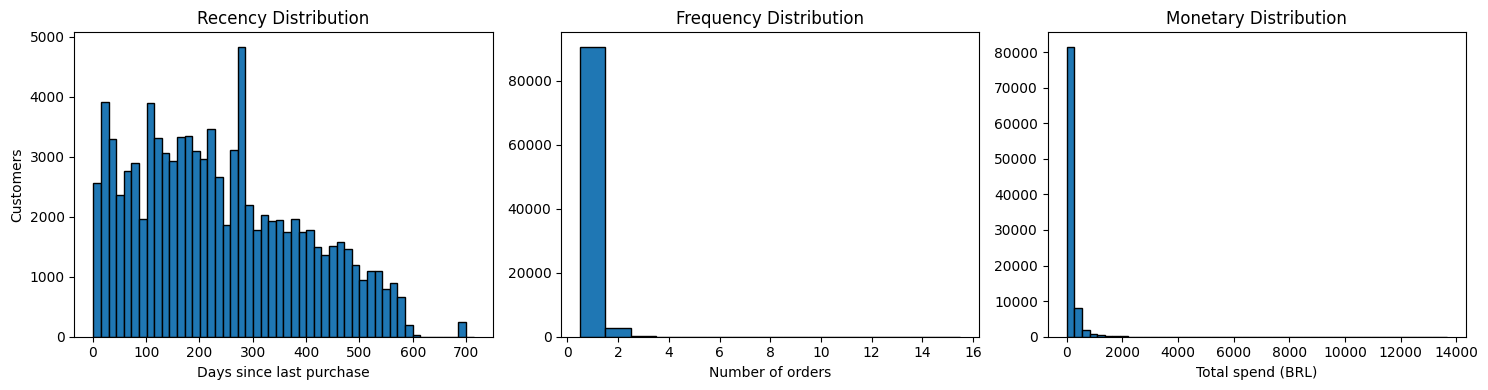

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["recency"], bins=50, edgecolor="black")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")
axes[0].set_ylabel("Customers")

axes[1].hist(rfm["frequency"], bins=range(1, rfm["frequency"].max() + 2),
             edgecolor="black", align="left")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of orders")

axes[2].hist(rfm["monetary"], bins=50, edgecolor="black")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total spend (BRL)")

plt.tight_layout()
plt.show()

- Recency is spread across 0–700 days, with a notable spike around 270–300 days likely reflecting a cohort of customers from a specific campaign or seasonal event.
- Frequency is almost entirely 1 — confirmed from EDA. Direct `qcut` on frequency would fail due to ties; `rank(method="first")` resolves this.
- Monetary is heavily right-skewed. A small number of customers account for disproportionate spend — consistent with the Pareto finding in EDA.
- Quantile-based scoring is the right approach given these distributions.

## Scoring

Each metric scored 1–4 using quartiles. Score 4 is always best.

In [6]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4, 3, 2, 1]   # reversed: lower recency = better
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm[["R_score", "F_score", "M_score"]].astype(int).describe()

,R_score,F_score,M_score
count,93358.000000,93358.00000,93358.000000
mean,2.502710,2.50000,2.499979
std,1.118305,1.11805,1.118050
min,1.000000,1.00000,1.000000
25%,2.000000,1.25000,1.250000
50%,3.000000,2.50000,2.000000
75%,4.000000,3.75000,3.750000
max,4.000000,4.00000,4.000000


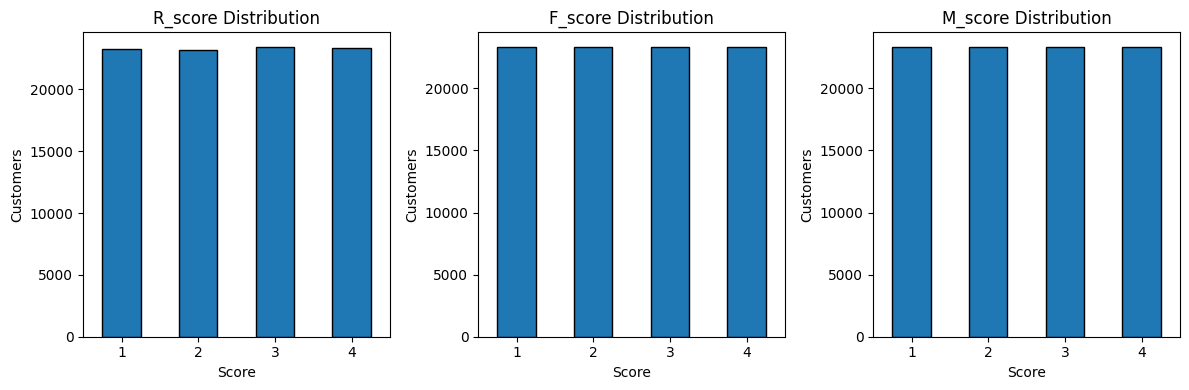

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, ["R_score", "F_score", "M_score"]):
    rfm[col].astype(int).value_counts().sort_index().plot(
        kind="bar", ax=ax, edgecolor="black"
    )
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel("Score")
    ax.set_ylabel("Customers")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Scores are approximately equally distributed across quartiles — expected with quantile binning.

## Rule-Based Segmentation

Segments assigned using Recency and Frequency scores only.

| Segment    | Condition         | Interpretation                          |
|------------|-------------------|-----------------------------------------|
| High Value | R≥3 and F≥3      | Active and frequent buyers              |
| Loyal      | R≥3 and F=2      | Active, moderate frequency              |
| Recent     | R≥3 and F=1      | New or recently returned                |
| At Risk    | R≤2 and F≥3      | Previously frequent, now inactive       |
| Average    | R≤2 and F=2      | Low engagement, moderate history        |
| Lost       | R≤2 and F=1      | Inactive one-time buyers                |

In [8]:
def assign_segment(row):
    r = int(row["R_score"])
    f = int(row["F_score"])

    if r >= 3 and f >= 3:
        return "High Value"
    elif r >= 3 and f >= 2:
        return "Loyal"
    elif r >= 3 and f == 1:
        return "Recent"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f == 1:
        return "Lost"
    else:
        return "Average"    # r <= 2, f == 2


rfm["segment"] = rfm.apply(assign_segment, axis=1)
rfm["segment"].value_counts()

segment
High Value    23491
At Risk       23188
Loyal         11679
Recent        11677
Lost          11663
Average       11660
Name: count, dtype: int64

In [9]:
segment_summary = (
    rfm
    .groupby("segment", as_index=False)
    .agg(
        customers           = ("customer_unique_id", "count"),
        avg_recency         = ("recency", "mean"),
        avg_frequency       = ("frequency", "mean"),
        total_revenue       = ("monetary", "sum"),
        avg_revenue_per_customer = ("monetary", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .round(2)
)

segment_summary

,segment,customers,avg_recency,avg_frequency,total_revenue,avg_revenue_per_customer
2,High Value,23491,112.25,1.08,4050397.41,172.42
0,At Risk,23188,364.11,1.06,3859325.15,166.44
3,Lost,11663,365.87,1.00,1896452.84,162.60
4,Loyal,11679,111.41,1.00,1884845.18,161.39
5,Recent,11677,112.69,1.00,1875081.38,160.58
1,Average,11660,364.47,1.00,1856359.81,159.21


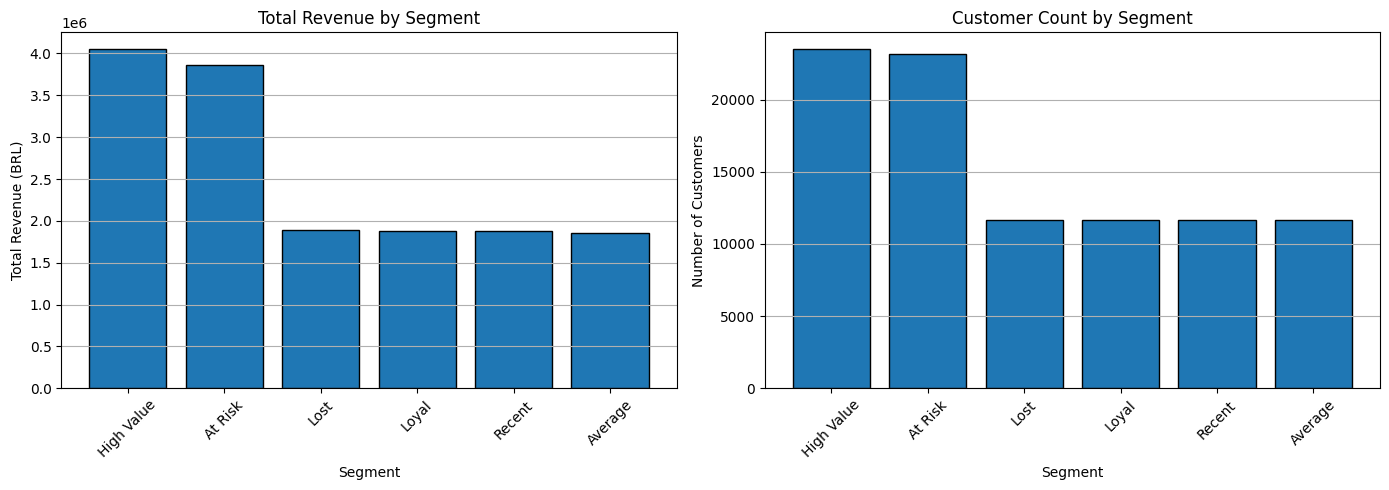

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(segment_summary["segment"], segment_summary["total_revenue"],
            edgecolor="black")
axes[0].set_title("Total Revenue by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Total Revenue (BRL)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y")

axes[1].bar(segment_summary["segment"], segment_summary["customers"],
            edgecolor="black")
axes[1].set_title("Customer Count by Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Observations

Segment sizes follow directly from the scoring logic:
- High Value and At Risk each contain ~25% of customers (R and F both split 50/50 at the median).
- The remaining four segments each contain ~12.5%.

Revenue picture:
- High Value (23,491 customers): BRL 4.05M total, BRL 172/customer avg.
- At Risk (23,188 customers): BRL 3.86M total, BRL 166/customer avg.
- Together these two segments account for ~52% of total revenue from ~50% of customers.

Key limitation to note: even "High Value" customers average only 1.08 orders, and "At Risk" averages 1.06. The frequency dimension has almost no range in this dataset — F_score captures relative rank within a near-uniform distribution, not meaningful behavioral differences in order count. Recency and monetary are the dimensions actually driving segment differentiation.

Primary business finding: At Risk is the most actionable segment. ~23K customers with BRL 166/customer average spend have not purchased in ~364 days on average. Reactivating even 10% of this segment represents approximately BRL 386K in recovered revenue.